### 🛢️ Lithofacies Classification
##### 01 — Data Exploration

---

👤 **Author:** NMM | 📅 **Date:** 2026 | 📁 **Input:** `labeled_data.csv`

**Pipeline:** `00 Combination` → **`01 Exploration ◀`** → `02 Preprocessing` → `03 EDA` → `04 Training` → `05 Evaluation`

---

##### 📌 Objectives
This notebook explores the combined labeled dataset before any cleaning or modeling.

1. Load the combined labeled dataset
2. Inspect column names, data types and shape
3. Review basic statistics for numerical columns
4. Identify categorical columns and their unique values
5. Detect and quantify missing values per column and per well
6. Explore well distribution and depth ranges
7. Analyze target class distribution and imbalance
8. Review lithology distribution per well
9. Explore Formation and Group columns
10. Check numerical feature ranges and skewness
11. Analyze feature correlations
12. Check for duplicate rows
13. Review the Confidence column
14. Generate a full summary report

---

In [1]:
# Cell 1 - Imports & Load Data
import pandas as pd
import numpy as np
import os

base_path      = "D:/Python/Lithofacies_Classification_NMM"
processed_path = os.path.join(base_path, "data/processed")

df = pd.read_csv(os.path.join(processed_path, "labeled_data.csv"))

print(f"✅ Data loaded!")
print(f"   Shape: {df.shape}")

✅ Data loaded!
   Shape: (122117, 32)


C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\587043343.py:9: DtypeWarning: Columns (0,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(processed_path, "labeled_data.csv"))


In [2]:
# Cell 2 - Column Overview
print("📋 Columns & Data Types:\n")
dtype_df = pd.DataFrame({
    "Column"   : df.columns,
    "Dtype"    : df.dtypes.values,
    "Non-Null" : df.notnull().sum().values,
    "Null"     : df.isnull().sum().values,
    "Unique"   : df.nunique().values
})
print(dtype_df.to_string(index=False))

📋 Columns & Data Types:

                           Column   Dtype  Non-Null   Null  Unique
                             WELL  object    100793  21324       9
                         DEPTH_MD float64    121744    373  121744
                            X_LOC float64    121744    373   13635
                            Y_LOC float64    121744    373    1267
                            Z_LOC float64    121744    373  121387
                            GROUP  object    100793  21324      12
                        FORMATION  object     94800  27317      47
                             CALI float64    108828  13289   98816
                             RSHA float64     21384 100733   21207
                             RMED float64    115198   6919  114642
                             RDEP float64    121744    373  121275
                             RHOB float64    113800   8317  111237
                               GR float64    121978    139  121565
                              SGR flo

In [3]:
# Cell 3 - Basic Statistics for Numerical Columns
print("📊 Numerical Columns Statistics:\n")
df.describe().T.round(3)

📊 Numerical Columns Statistics:



,count,mean,std,min,25%,50%,75%,max
DEPTH_MD,121744.0,2076.366,828.825,376.231,1472.627,2010.696,2642.957,4319.791
X_LOC,121744.0,498232.350,37936.876,433906.750,452405.906,515574.438,536104.688,544117.438
Y_LOC,121744.0,6631550.900,141746.970,6458300.500,6495507.000,6552710.000,6759829.500,6853475.000
Z_LOC,121744.0,-2041.771,821.576,-4286.083,-2594.965,-1978.171,-1447.033,-353.230
CALI,108828.0,12.091,2.742,8.025,8.931,12.317,12.712,24.312
RSHA,21384.0,24.564,186.374,0.119,0.704,0.957,1.673,1999.717
RMED,115198.0,3.391,36.410,0.000,0.791,1.242,2.020,1996.105
RDEP,121744.0,25.133,109.828,0.000,0.836,1.326,2.553,1999.751
RHOB,113800.0,2.298,0.219,1.128,2.157,2.315,2.475,3.210
GR,121978.0,72.964,35.505,1.132,50.977,74.714,95.784,1141.292


In [4]:
# Cell 5 - Missing Values Analysis
missing       = df.isnull().sum()
missing_pct   = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Column"        : missing.index,
    "Missing Count" : missing.values,
    "Missing %"     : missing_pct.values
}).sort_values("Missing %", ascending=False)

print("🔍 Missing Values Report:\n")
print(missing_df.to_string(index=False))
print(f"\n  Columns with NO missing : {(missing == 0).sum()}")
print(f"  Columns WITH missing    : {(missing  > 0).sum()}")
print(f"  Total missing cells     : {df.isnull().sum().sum():,}")
print(f"  Overall missing %       : {(df.isnull().sum().sum() / df.size * 100):.2f}%")

🔍 Missing Values Report:

                           Column  Missing Count  Missing %
                        MUDWEIGHT         122117     100.00
                              SGR         120978      99.07
                              RXO         111681      91.45
                             RMIC         106936      87.57
                       Unnamed: 0         100793      82.54
                             DEPT         100793      82.54
                             RSHA         100733      82.49
                             DCAL          79013      64.70
                               SP          72725      59.55
                             ROPA          57896      47.41
                              DTS          56145      45.98
                               BS          39391      32.26
                              ROP          30967      25.36
                        FORMATION          27317      22.37
                            GROUP          21324      17.46
              

In [5]:
# Cell 6 - Missing % Per Column Per Well
print("🔍 Missing % Per Column Per Well:\n")
missing_per_well = df.groupby("WELL").apply(
    lambda x: x.isnull().mean() * 100
).round(2)

print(missing_per_well.to_string())

🔍 Missing % Per Column Per Well:

           WELL  DEPTH_MD  X_LOC  Y_LOC  Z_LOC  GROUP  FORMATION  CALI    RSHA   RMED  RDEP   RHOB   GR     SGR   NPHI     PEF   DTC      SP     BS     ROP     DTS    DCAL   DRHO  MUDWEIGHT    RMIC    ROPA     RXO  FORCE_2020_LITHOFACIES_LITHOLOGY  FORCE_2020_LITHOFACIES_CONFIDENCE  SOURCE_FILE  Unnamed: 0   DEPT
WELL                                                                                                                                                                                                                                                                                                                      
15/9-23     0.0       0.0    0.0    0.0    0.0    0.0       0.00  0.00  100.00   0.49   0.0   0.49  0.0  100.00   0.24    2.04  1.10  100.00    0.0    0.33    5.78    0.00   0.00      100.0  100.00    0.35  100.00                               0.0                               0.04          0.0       100.0  100.0
16/2-7      0.0      

C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\419327805.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_per_well = df.groupby("WELL").apply(


In [6]:
# Cell 7 - Wells Overview
print("🛢️  Wells in Dataset:\n")
well_df = df.groupby("WELL").agg(
    Row_Count   = ("DEPTH_MD", "count"),
    Depth_Min   = ("DEPTH_MD", "min"),
    Depth_Max   = ("DEPTH_MD", "max"),
    Depth_Range = ("DEPTH_MD", lambda x: x.max() - x.min())
).reset_index()

print(well_df.to_string(index=False))
print(f"\n  Total unique wells: {df['WELL'].nunique()}")

🛢️  Wells in Dataset:

     WELL  Row_Count   Depth_Min   Depth_Max  Depth_Range
  15/9-23      11063 1518.280000 3212.624000     1694.344
   16/2-7      11683  704.116002 2480.540002     1776.424
   16/7-6      10222 1110.934400 2698.422400     1587.488
   17/4-1      17271 1147.550793 3834.150793     2686.600
  25/10-9      10788 1333.088800 2972.712800     1639.624
  31/2-10       9033  456.224000 1829.088000     1372.864
31/2-21 S       7840 1999.928400 3191.608400     1191.680
 34/3-2 S      12216 2380.574800 4319.790800     1939.216
   35/9-7      10677 1351.154800 2973.906800     1622.752

  Total unique wells: 9


In [7]:
# Cell 8 - Target Class Distribution
print("🎯 Lithology Class Distribution:\n")
class_df = df["FORCE_2020_LITHOFACIES_LITHOLOGY"].value_counts().reset_index()
class_df.columns = ["Lithology Code", "Count"]
class_df["Percentage %"] = (class_df["Count"] / len(df) * 100).round(2)

print(class_df.to_string(index=False))
print(f"\n  Total classes : {class_df.shape[0]}")
print(f"  Most common   : {class_df.iloc[0]['Lithology Code']} ({class_df.iloc[0]['Percentage %']}%)")
print(f"  Rarest class  : {class_df.iloc[-1]['Lithology Code']} ({class_df.iloc[-1]['Percentage %']}%)")
print(f"  Imbalance ratio: {(class_df.iloc[0]['Count'] / class_df.iloc[-1]['Count']):.1f}x")

🎯 Lithology Class Distribution:

 Lithology Code  Count  Percentage %
        65000.0  69305         56.75
        30000.0  14794         12.11
        65030.0  10507          8.60
        70000.0   8721          7.14
        88000.0   6498          5.32
        80000.0   5266          4.31
        70032.0   2905          2.38
        99000.0   2366          1.94
        86000.0    597          0.49
        74000.0    269          0.22
        90000.0    196          0.16

  Total classes : 11
  Most common   : 65000.0 (56.75%)
  Rarest class  : 90000.0 (0.16%)
  Imbalance ratio: 353.6x


In [8]:
# Cell 9 - Lithology Distribution Per Well
print("🛢️  Lithology Classes Per Well:\n")
litho_per_well = df.groupby("WELL")["FORCE_2020_LITHOFACIES_LITHOLOGY"]\
                   .value_counts().unstack(fill_value=0)
print(litho_per_well.to_string())

🛢️  Lithology Classes Per Well:

FORCE_2020_LITHOFACIES_LITHOLOGY  30000.0  65000.0  65030.0  70000.0  70032.0  74000.0  80000.0  86000.0  88000.0  90000.0  99000.0
WELL                                                                                                                               
15/9-23                               563     6731     1060     1630       29        0      912        0        0       64       74
16/2-7                               2759     4715      415     2315        0        0     1232      122        0        0      125
16/7-6                                195     6798      995      238     1526       31      381        0        0        0       58
17/4-1                               1833     5124      952      744     1350      154      141      475     6498        0        0
25/10-9                              1237     6226      651     1950        0        0      397        0        0        5      322
31/2-10                               966  

In [9]:
# Cell 10 - Formation & Group Overview
print("🪨  GROUP Distribution:\n")
print(df["GROUP"].value_counts().to_string())

print("\n\n🪨  FORMATION Distribution:\n")
print(df["FORMATION"].value_counts().to_string())

🪨  GROUP Distribution:

GROUP
SHETLAND GP.        24270
HORDALAND GP.       22290
VIKING GP.          13946
ROGALAND GP.        10687
ZECHSTEIN GP.        8015
CROMER KNOLL GP.     6395
VESTLAND GP.         3957
DUNLIN GP.           3721
NORDLAND GP.         3637
ROTLIEGENDES GP.     1558
BAAT GP.             1348
HEGRE GP.             969


🪨  FORMATION Distribution:

FORMATION
Kyrre Fm.                 10236
Smith Bank Fm.             8134
Skade Fm.                  7671
Utsira Fm.                 7244
Lista Fm.                  5833
Tor Fm.                    5612
Heather Fm.                4231
Skagerrak Fm.              4008
Grid Fm.                   3566
Sognefjord Fm.             3309
Roedby Fm.                 2830
Aasgard Fm.                2789
Draupne Fm.                2717
Fensfjord Fm.              2672
Tryggvason Fm.             2106
Hod Fm.                    2052
Kupferschiefer Fm.         1624
Blodoeks Fm.               1587
Balder Fm.                 1577
Sele Fm.  

In [10]:
# Cell 11 - Numerical Features Range & Outlier Check
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target and confidence columns
exclude  = ["FORCE_2020_LITHOFACIES_LITHOLOGY", "FORCE_2020_LITHOFACIES_CONFIDENCE"]
num_cols = [c for c in num_cols if c not in exclude]

print("📐 Numerical Features Range:\n")
range_df = pd.DataFrame({
    "Column" : num_cols,
    "Min"    : df[num_cols].min().values.round(3),
    "Max"    : df[num_cols].max().values.round(3),
    "Mean"   : df[num_cols].mean().values.round(3),
    "Std"    : df[num_cols].std().values.round(3),
    "Skew"   : df[num_cols].skew().values.round(3)
})
print(range_df.to_string(index=False))

📐 Numerical Features Range:

    Column         Min         Max        Mean        Std    Skew
  DEPTH_MD     376.231    4319.791    2076.366    828.825   0.335
     X_LOC  433906.750  544117.438  498232.350  37936.876  -0.452
     Y_LOC 6458300.500 6853475.000 6631550.900 141746.970   0.127
     Z_LOC   -4286.083    -353.230   -2041.771    821.576  -0.351
      CALI       8.025      24.312      12.091      2.742   0.648
      RSHA       0.119    1999.717      24.564    186.374   8.878
      RMED       0.000    1996.105       3.391     36.410  39.198
      RDEP       0.000    1999.751      25.133    109.828   7.760
      RHOB       1.128       3.210       2.298      0.219  -0.586
        GR       1.132    1141.292      72.964     35.505   1.393
       SGR      26.545     344.231      70.300     26.824   5.502
      NPHI      -0.015       0.906       0.327      0.128  -0.081
       PEF       0.000     242.159       4.043      3.997  14.902
       DTC      48.269     180.842     112.055 

In [11]:
# Cell 12 - Correlation Matrix
print("🔗 Correlation Matrix (Top Correlated Pairs):\n")
corr_matrix = df[num_cols].corr().abs()

# Extract upper triangle pairs
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs  = upper.stack().reset_index()
corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
corr_pairs  = corr_pairs.sort_values("Correlation", ascending=False)

print("  Top 20 Highly Correlated Pairs:\n")
print(corr_pairs.head(20).to_string(index=False))

print("\n  Bottom 10 Least Correlated Pairs:\n")
print(corr_pairs.tail(10).to_string(index=False))

🔗 Correlation Matrix (Top Correlated Pairs):

  Top 20 Highly Correlated Pairs:

 Feature 1  Feature 2  Correlation
  DEPTH_MD       DEPT     1.000000
     Z_LOC       DEPT     0.999998
  DEPTH_MD      Z_LOC     0.999137
       DTC        DTS     0.949047
Unnamed: 0       DEPT     0.937154
     Z_LOC Unnamed: 0     0.935094
  DEPTH_MD Unnamed: 0     0.934365
       ROP       ROPA     0.933055
        GR        SGR     0.932986
      CALI         BS     0.905322
      RSHA        RXO     0.899217
       DTC       DEPT     0.882169
       DTC Unnamed: 0     0.877263
      NPHI        DTC     0.850673
     X_LOC         SP     0.846673
        SP       DEPT     0.845148
        BS       DEPT     0.841534
      NPHI        DTS     0.833829
      CALI       DEPT     0.798677
        SP Unnamed: 0     0.798024

  Bottom 10 Least Correlated Pairs:

Feature 1  Feature 2  Correlation
     RSHA        PEF     0.008803
    Y_LOC        DTC     0.008542
    X_LOC        DTC     0.008345
      ROP 

In [12]:
# Cell 13 - Duplicate Rows Check
dupes = df.duplicated().sum()
print(f"🔁 Duplicate Rows  : {dupes:,}")
print(f"   Unique Rows     : {len(df) - dupes:,}")
print(f"   Duplicate %     : {(dupes / len(df) * 100):.2f}%")

🔁 Duplicate Rows  : 0
   Unique Rows     : 122,117
   Duplicate %     : 0.00%


In [13]:
# Cell 14 - Confidence Column Analysis
print("🎯 FORCE_2020_LITHOFACIES_CONFIDENCE Distribution:\n")
conf = df["FORCE_2020_LITHOFACIES_CONFIDENCE"].value_counts().reset_index()
conf.columns = ["Confidence Level", "Count"]
conf["Percentage %"] = (conf["Count"] / len(df) * 100).round(2)
print(conf.to_string(index=False))
print("\n⚠️  Note: This column will be DROPPED before training to avoid data leakage!")

🎯 FORCE_2020_LITHOFACIES_CONFIDENCE Distribution:

 Confidence Level  Count  Percentage %
              1.0 109344         89.54
              2.0   8589          7.03
              3.0   3474          2.84

⚠️  Note: This column will be DROPPED before training to avoid data leakage!


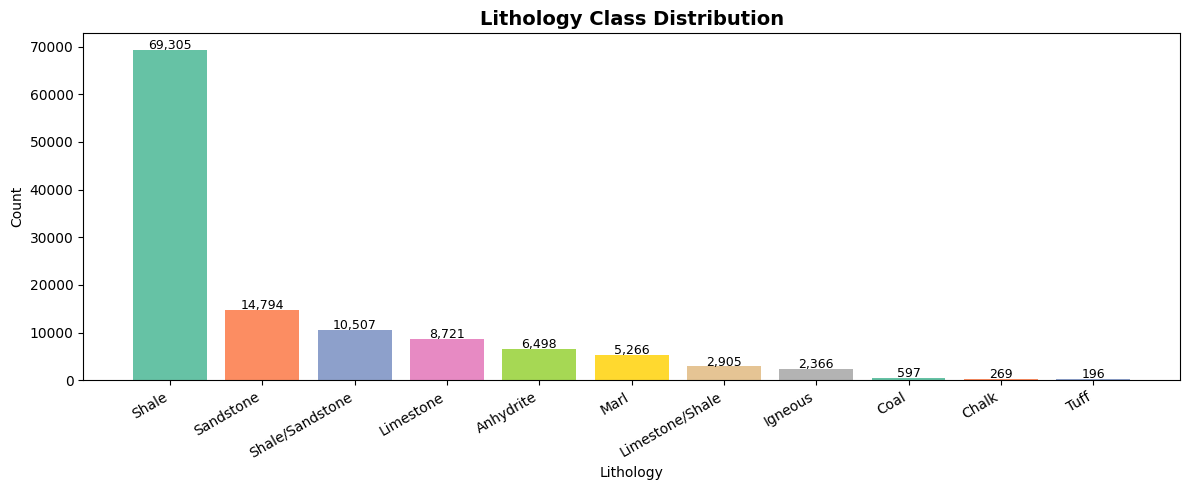

💾 Saved → reports/figures/class_distribution.png


In [15]:
# Cell 15 - Class Distribution Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns

litho_map = {
    30000: "Sandstone",
    65000: "Shale",
    65030: "Shale/Sandstone",
    70000: "Limestone",
    70032: "Limestone/Shale",
    74000: "Chalk",
    80000: "Marl",
    86000: "Coal",
    88000: "Anhydrite",
    90000: "Tuff",
    99000: "Igneous"
}

df["LITHO_NAME"] = df["FORCE_2020_LITHOFACIES_LITHOLOGY"].map(litho_map)

class_counts = df["LITHO_NAME"].value_counts()

plt.figure(figsize=(12, 5))
bars = plt.bar(class_counts.index, class_counts.values, color=sns.color_palette("Set2", len(class_counts)))
plt.title("Lithology Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Lithology")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{val:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/class_distribution.png", dpi=150)
plt.show()
print("💾 Saved → reports/figures/class_distribution.png")

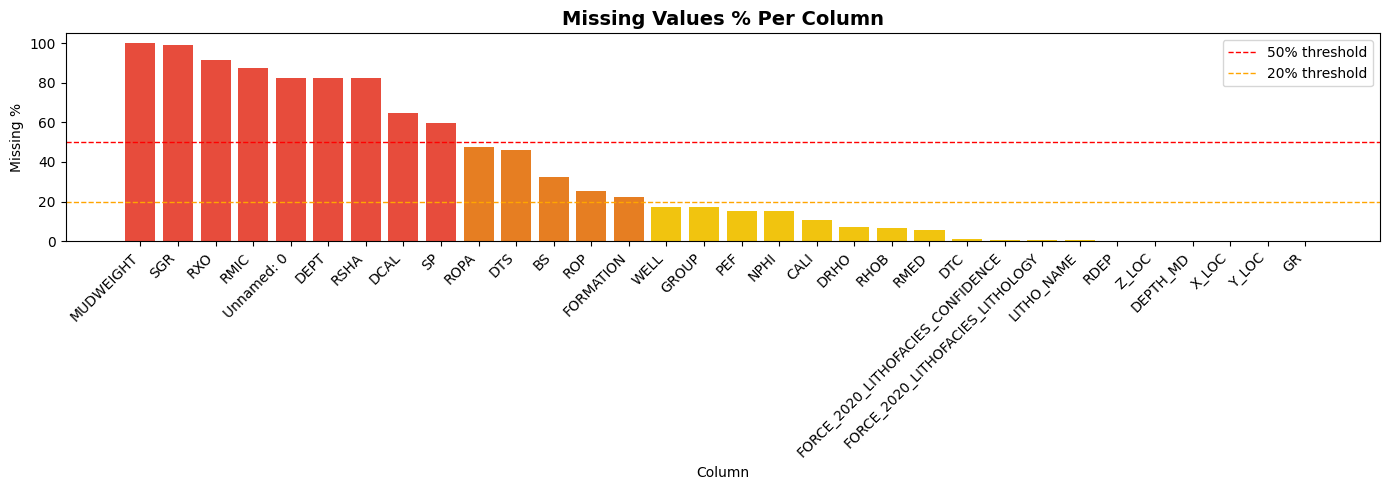

💾 Saved → reports/figures/missing_values.png


In [16]:
# Cell 16 - Missing Values Bar Chart
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(14, 5))
colors = ["#e74c3c" if x > 50 else "#e67e22" if x > 20 else "#f1c40f" for x in missing_pct.values]
bars = plt.bar(missing_pct.index, missing_pct.values, color=colors)
plt.axhline(y=50, color="red",    linestyle="--", linewidth=1, label="50% threshold")
plt.axhline(y=20, color="orange", linestyle="--", linewidth=1, label="20% threshold")
plt.title("Missing Values % Per Column", fontsize=14, fontweight="bold")
plt.xlabel("Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/missing_values.png", dpi=150)
plt.show()
print("💾 Saved → reports/figures/missing_values.png")

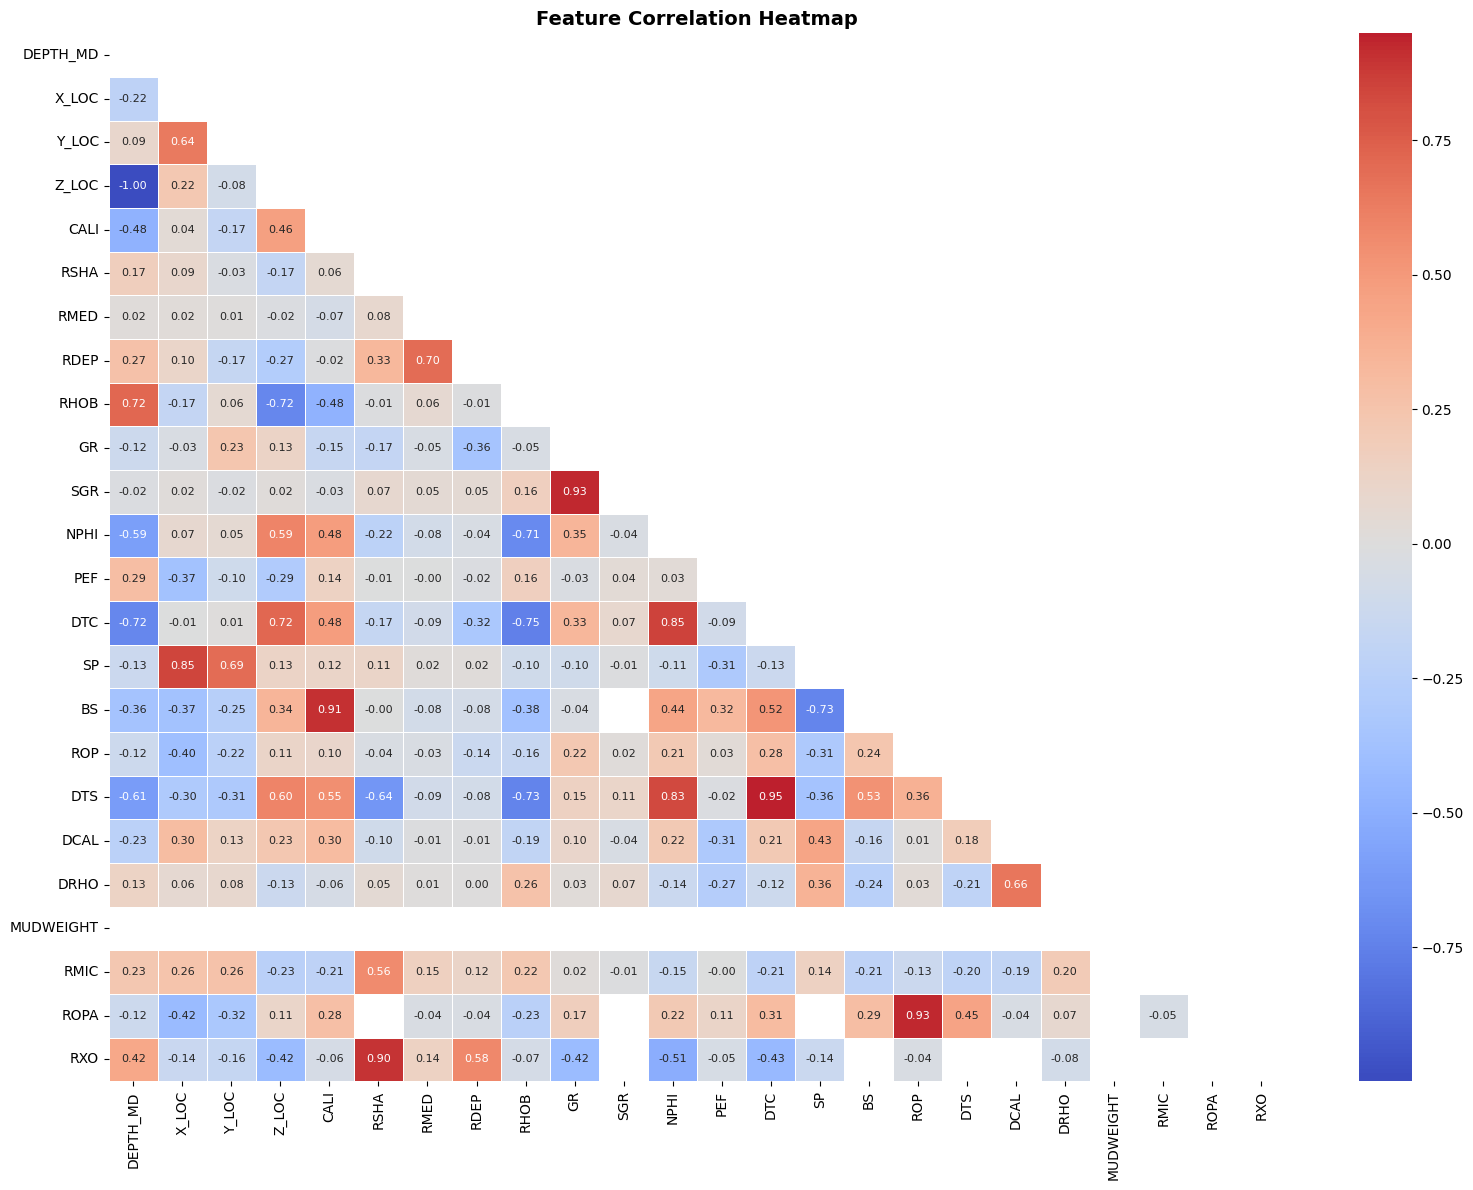

💾 Saved → reports/figures/correlation_heatmap.png


In [17]:
# Cell 17 - Correlation Heatmap
num_cols = df.select_dtypes(include=np.number).columns.tolist()
drop_cols = ["FORCE_2020_LITHOFACIES_LITHOLOGY", "FORCE_2020_LITHOFACIES_CONFIDENCE",
             "Unnamed: 0", "DEPT"]
num_cols = [c for c in num_cols if c not in drop_cols]

corr = df[num_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/correlation_heatmap.png", dpi=150)
plt.show()
print("💾 Saved → reports/figures/correlation_heatmap.png")

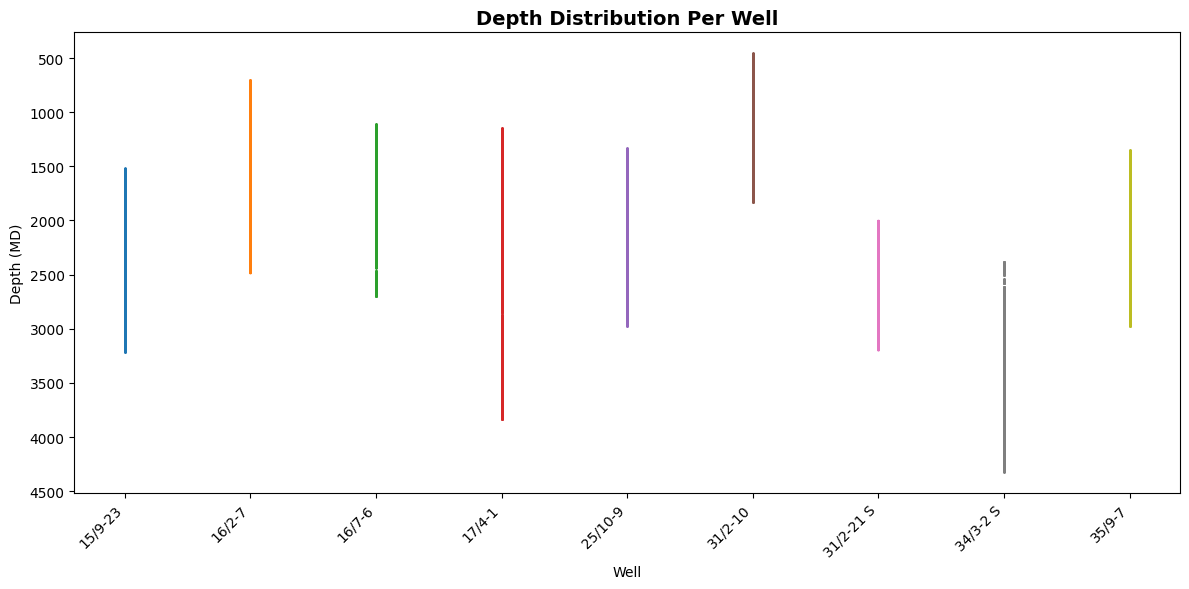

💾 Saved → reports/figures/depth_per_well.png


In [18]:
# Cell 18 - Depth Distribution Per Well
plt.figure(figsize=(12, 6))
for well in df["WELL"].dropna().unique():
    well_data = df[df["WELL"] == well]["DEPTH_MD"]
    plt.plot([well] * len(well_data), well_data, ".", markersize=1, alpha=0.3)

plt.title("Depth Distribution Per Well", fontsize=14, fontweight="bold")
plt.xlabel("Well")
plt.ylabel("Depth (MD)")
plt.xticks(rotation=45, ha="right")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/depth_per_well.png", dpi=150)
plt.show()
print("💾 Saved → reports/figures/depth_per_well.png")

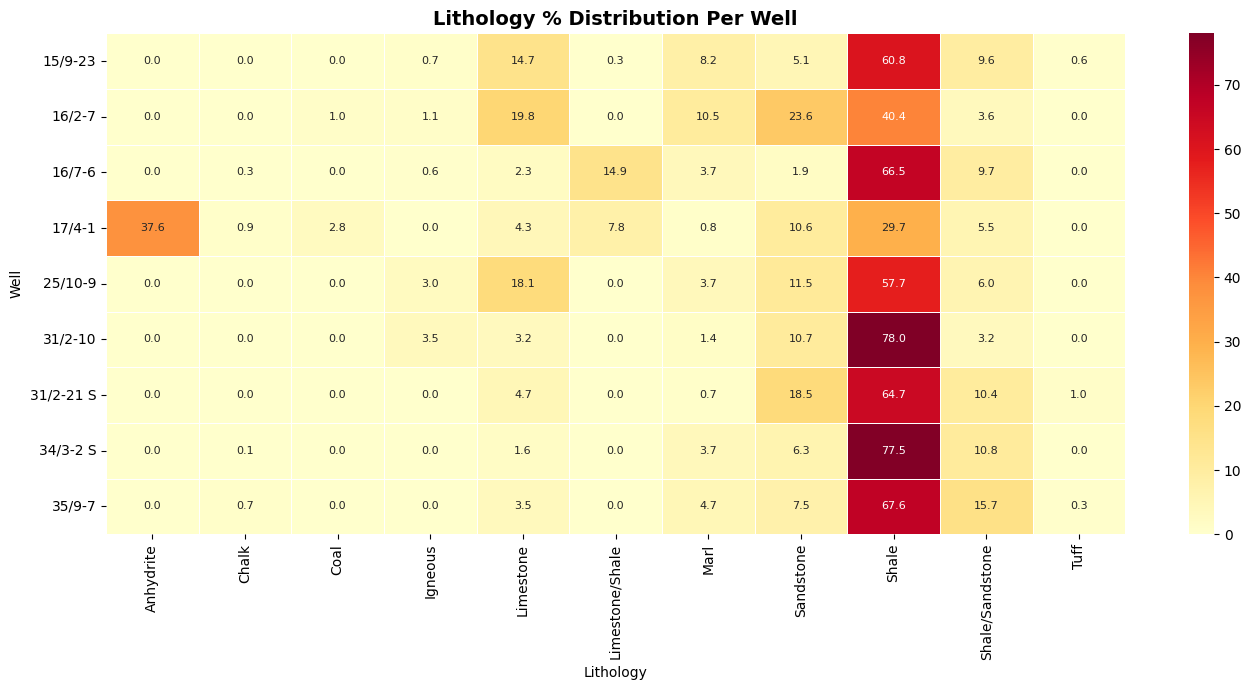

💾 Saved → reports/figures/litho_per_well.png


In [19]:
# Cell 19 - Lithology Per Well Heatmap
litho_well = df.groupby(["WELL", "LITHO_NAME"]).size().unstack(fill_value=0)
litho_well_pct = litho_well.div(litho_well.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 7))
sns.heatmap(litho_well_pct, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Lithology % Distribution Per Well", fontsize=14, fontweight="bold")
plt.xlabel("Lithology")
plt.ylabel("Well")
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/litho_per_well.png", dpi=150)
plt.show()
print("💾 Saved → reports/figures/litho_per_well.png")

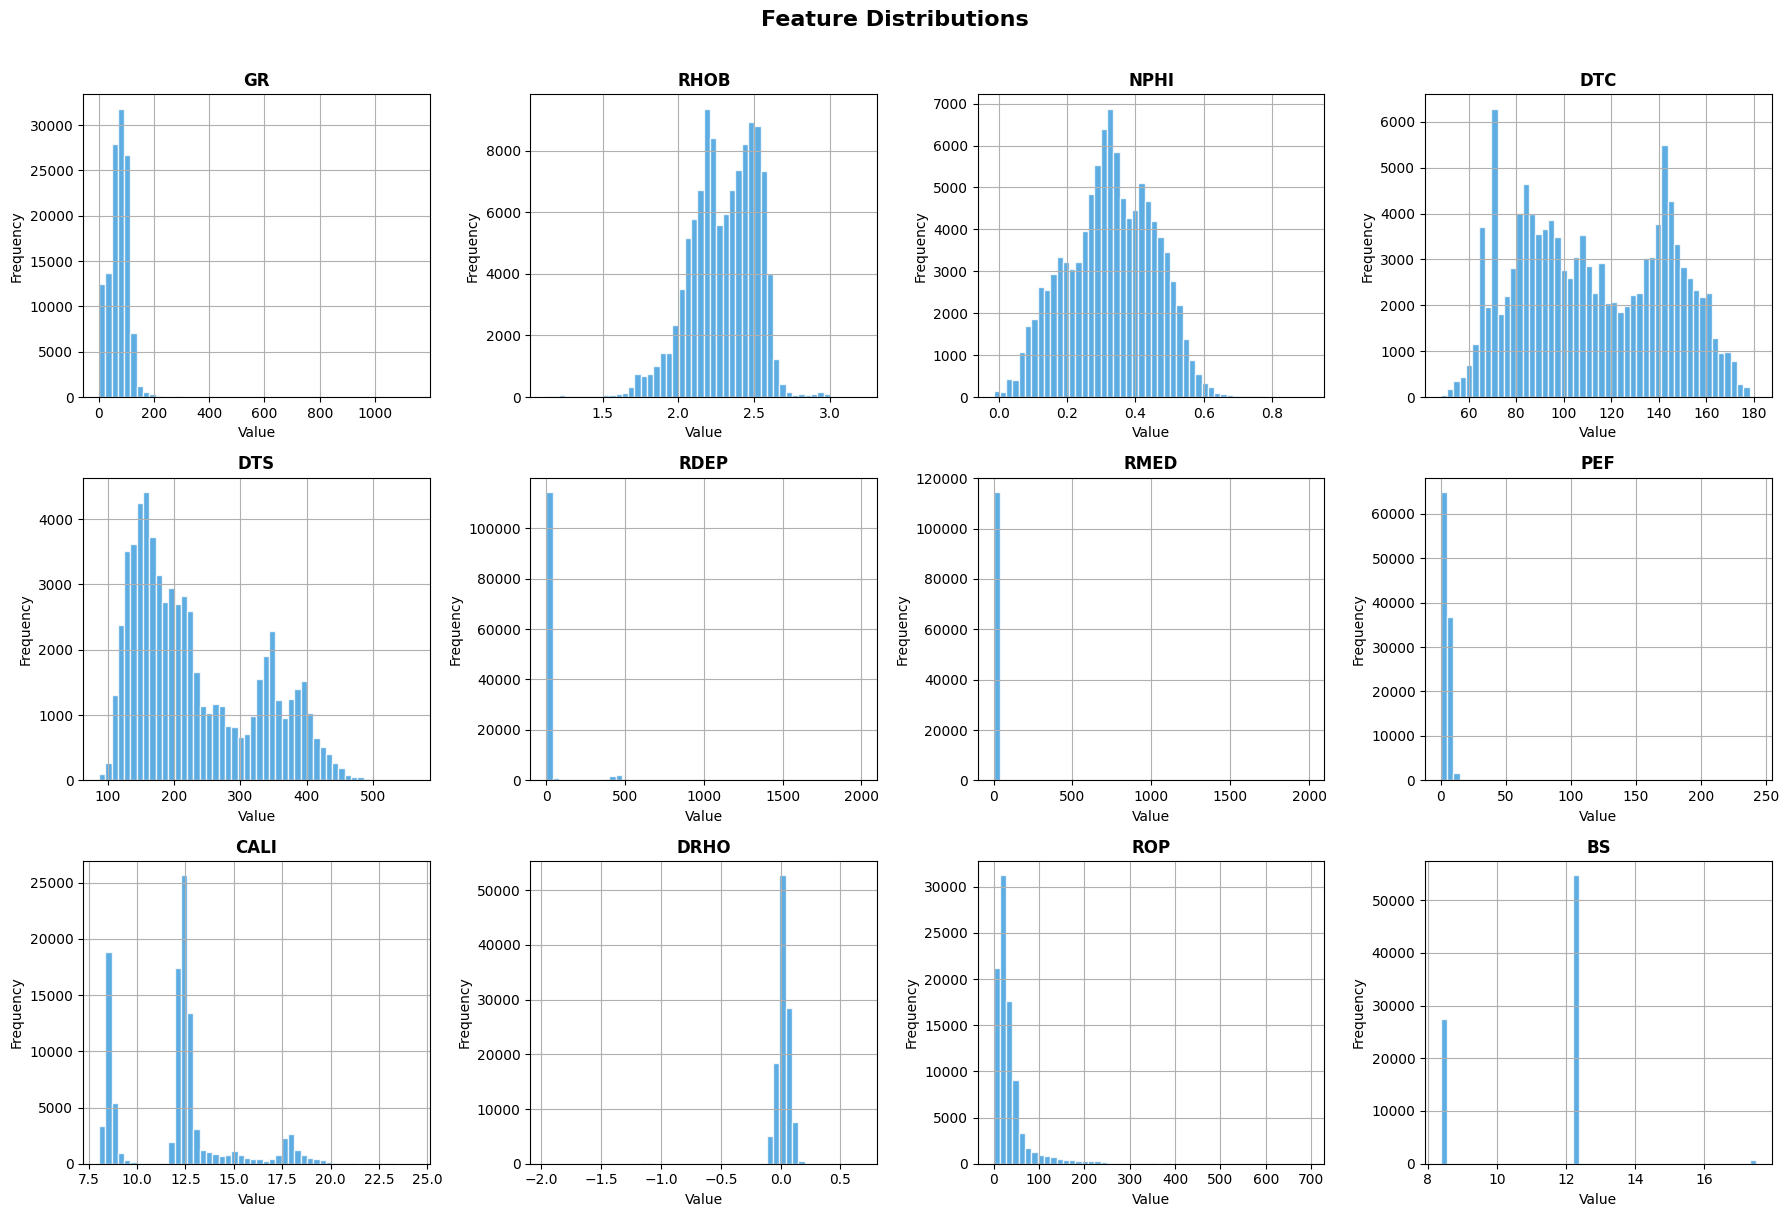

💾 Saved → reports/figures/feature_distributions.png


In [20]:
# Cell 20 - Feature Distributions
features = ["GR", "RHOB", "NPHI", "DTC", "DTS", "RDEP", "RMED", "PEF", "CALI", "DRHO", "ROP", "BS"]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    if col in df.columns:
        df[col].dropna().hist(bins=50, ax=axes[i], color="#3498db", edgecolor="white", alpha=0.8)
        axes[i].set_title(col, fontweight="bold")
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

plt.suptitle("Feature Distributions", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/feature_distributions.png", dpi=150)
plt.show()
print("💾 Saved → reports/figures/feature_distributions.png")

C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\3284188142.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="LITHO_NAME", y=col, order=order,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\3284188142.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="LITHO_NAME", y=col, order=order,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\3284188142.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="LITHO_NAME", y=col, order=order,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\3284188142.py:

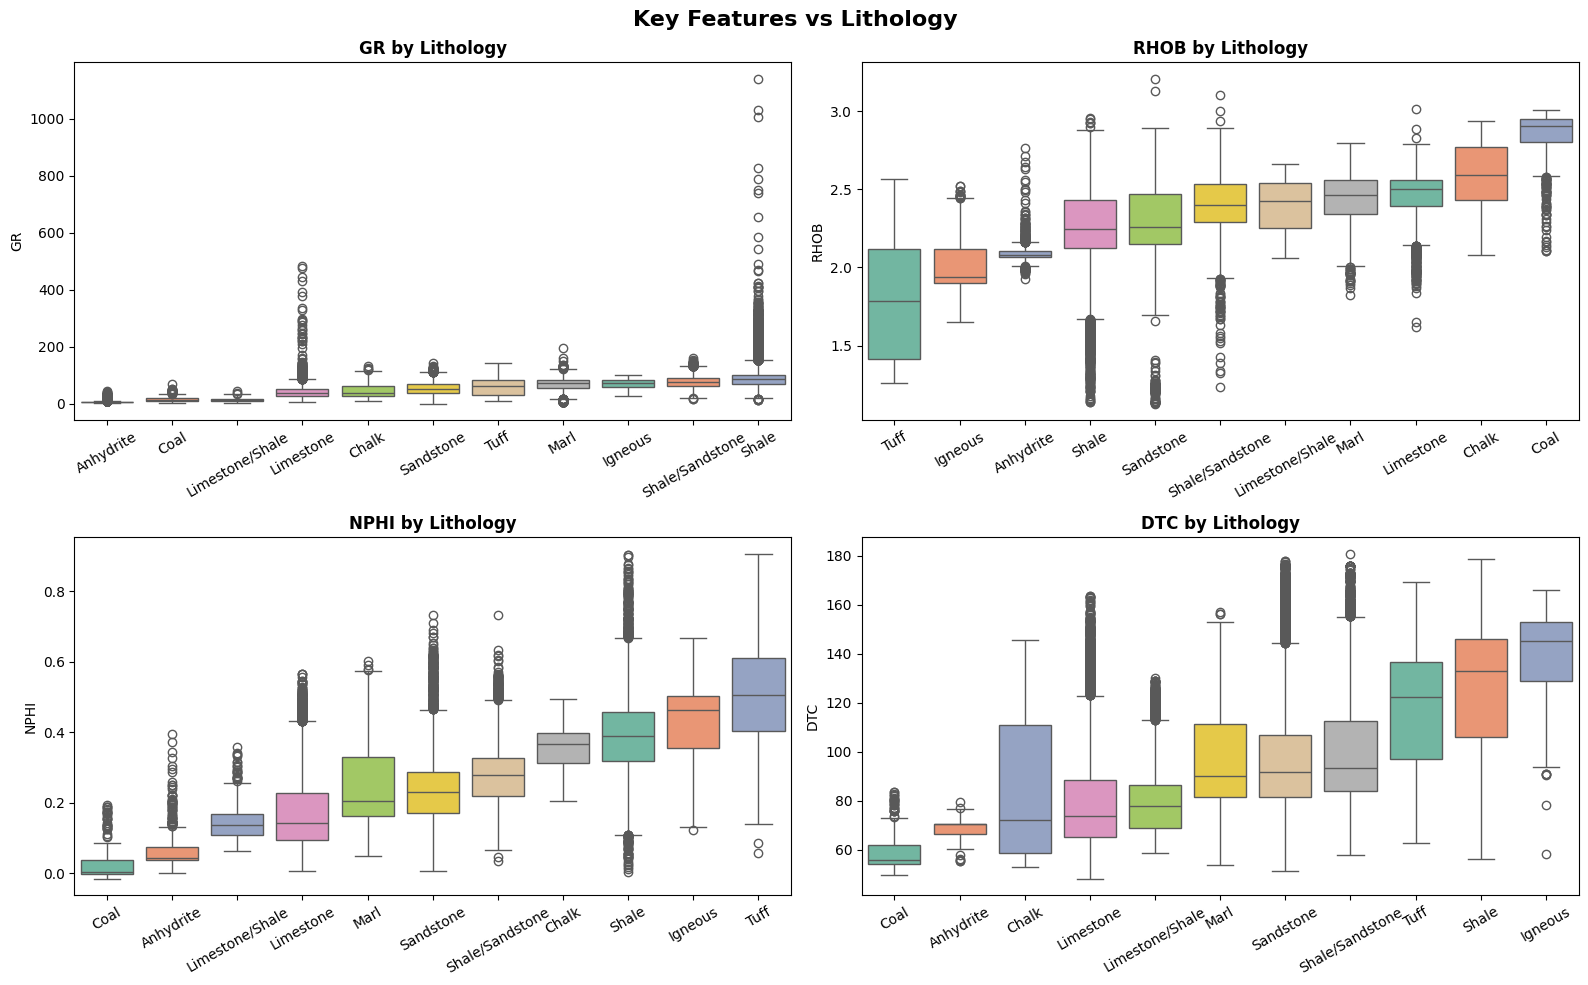

💾 Saved → reports/figures/boxplot_features.png


In [21]:
# Cell 21 - Boxplot Key Features vs Lithology
features = ["GR", "RHOB", "NPHI", "DTC"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    if col in df.columns:
        data = df[[col, "LITHO_NAME"]].dropna()
        order = data.groupby("LITHO_NAME")[col].median().sort_values().index
        sns.boxplot(data=data, x="LITHO_NAME", y=col, order=order,
                    palette="Set2", ax=axes[i])
        axes[i].set_title(f"{col} by Lithology", fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Key Features vs Lithology", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/boxplot_features.png", dpi=150)
plt.show()
print("💾 Saved → reports/figures/boxplot_features.png")

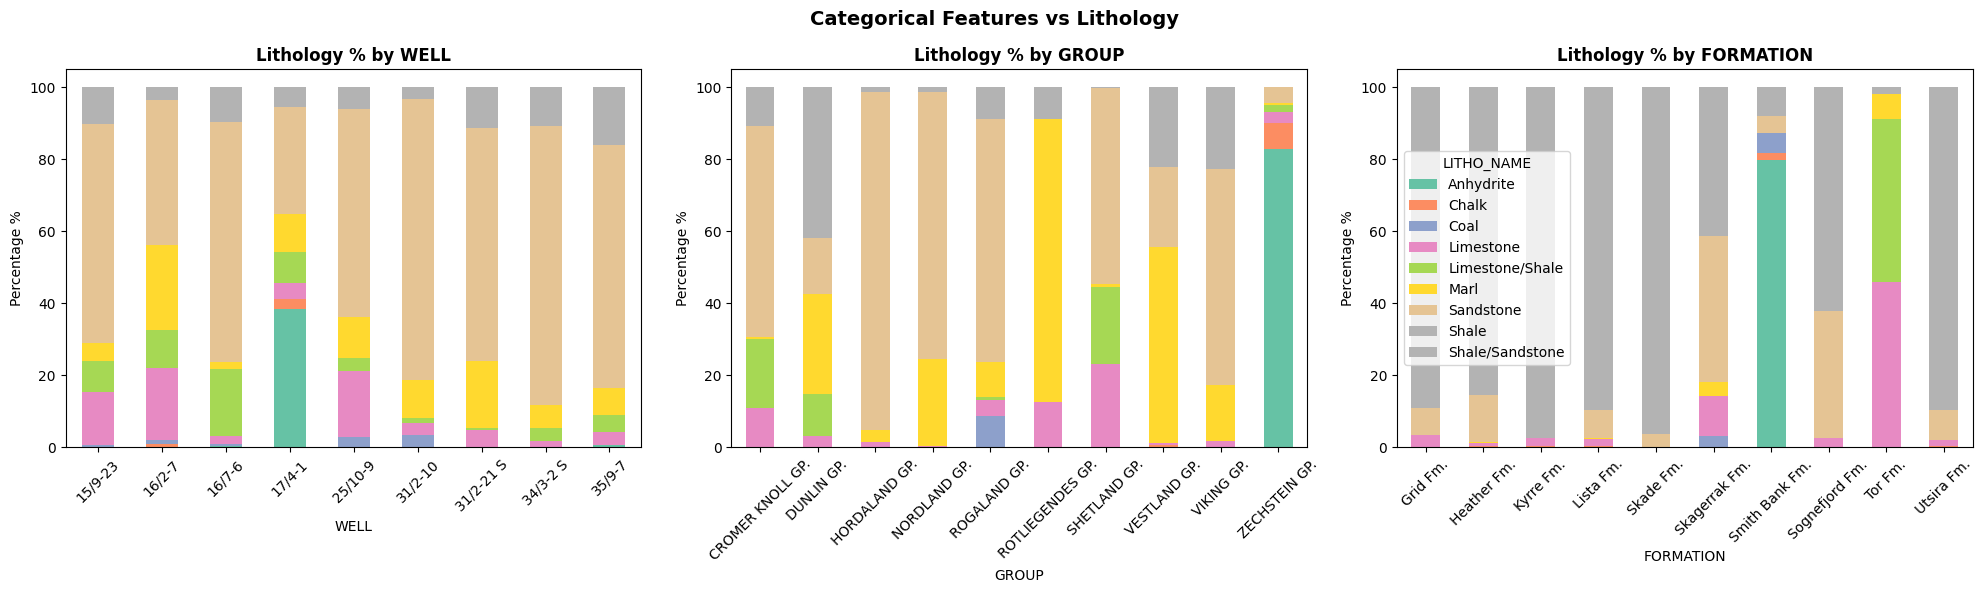

💾 Saved → reports/figures/categorical_vs_litho.png


In [22]:
# Cell 22 - Categorical Columns vs Lithology
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col in zip(axes, ["WELL", "GROUP", "FORMATION"]):
    top = df[col].value_counts().head(10).index
    data = df[df[col].isin(top)]
    ct = pd.crosstab(data[col], data["LITHO_NAME"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", legend=(col == "FORMATION"))
    ax.set_title(f"Lithology % by {col}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Percentage %")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Categorical Features vs Lithology", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/categorical_vs_litho.png", dpi=150)
plt.show()
print("💾 Saved → reports/figures/categorical_vs_litho.png")

In [23]:
# Cell 23 - Final Preprocessing Plan
print("=" * 60)
print("         ✅ FINAL PREPROCESSING PLAN")
print("=" * 60)

print("""
🗑️  COLUMNS TO DROP (7):
    • MUDWEIGHT    → 100% missing
    • SGR          → 99% missing
    • RXO          → 91% missing
    • RMIC         → 87% missing
    • RSHA         → 82% missing
    • DCAL         → 64% missing
    • SP           → 59% missing
    • ROPA         → 47% missing
    • Unnamed: 0   → index artifact
    • DEPT         → duplicate of DEPTH_MD (corr=1.0)
    • Z_LOC        → duplicate of DEPTH_MD (corr=0.999)
    • SOURCE_FILE  → not a feature
    • FORCE_2020_LITHOFACIES_CONFIDENCE → data leakage

🧹  ROWS TO DROP:
    • 693 rows where LITHOLOGY target is missing (0.57%)

🔧  MISSING VALUE IMPUTATION:
    • DTS, BS, ROP, PEF, NPHI  → median per WELL
    • CALI, DRHO, RHOB, RMED   → median per WELL
    • RDEP, DTC, GR            → median per WELL
    • FORMATION, GROUP         → mode per WELL

📐  SKEWED FEATURES — LOG TRANSFORM:
    • RMED, RDEP, RSHA, PEF, ROP, DRHO

🏷️  CATEGORICAL ENCODING:
    • WELL, FORMATION, GROUP   → Label Encoding

🎯  TARGET:
    • FORCE_2020_LITHOFACIES_LITHOLOGY → Label Encode (0–10)

✅  FINAL FEATURES TO KEEP:
    • DEPTH_MD, X_LOC, Y_LOC
    • CALI, RMED, RDEP, RHOB, GR, NPHI, PEF
    • DTC, DTS, BS, ROP, DRHO
    • WELL, FORMATION, GROUP (encoded)
""")

print("=" * 60)
print("  📓 Next → 02_Data_Preprocessing.ipynb")
print("=" * 60)

         ✅ FINAL PREPROCESSING PLAN

🗑️  COLUMNS TO DROP (7):
    • MUDWEIGHT    → 100% missing
    • SGR          → 99% missing
    • RXO          → 91% missing
    • RMIC         → 87% missing
    • RSHA         → 82% missing
    • DCAL         → 64% missing
    • SP           → 59% missing
    • ROPA         → 47% missing
    • Unnamed: 0   → index artifact
    • DEPT         → duplicate of DEPTH_MD (corr=1.0)
    • Z_LOC        → duplicate of DEPTH_MD (corr=0.999)
    • SOURCE_FILE  → not a feature
    • FORCE_2020_LITHOFACIES_CONFIDENCE → data leakage

🧹  ROWS TO DROP:
    • 693 rows where LITHOLOGY target is missing (0.57%)

🔧  MISSING VALUE IMPUTATION:
    • DTS, BS, ROP, PEF, NPHI  → median per WELL
    • CALI, DRHO, RHOB, RMED   → median per WELL
    • RDEP, DTC, GR            → median per WELL
    • FORMATION, GROUP         → mode per WELL

📐  SKEWED FEATURES — LOG TRANSFORM:
    • RMED, RDEP, RSHA, PEF, ROP, DRHO

🏷️  CATEGORICAL ENCODING:
    • WELL, FORMATION, GROUP   → La

In [24]:
# Cell 24 - X_LOC & Y_LOC vs WELL (are they constant per well?)
print("📍 X_LOC & Y_LOC unique values per WELL:\n")
loc_check = df.groupby("WELL")[["X_LOC", "Y_LOC"]].nunique()
print(loc_check)
print("\n💡 If all values = 1, coordinates are constant per well → safe to DROP")

📍 X_LOC & Y_LOC unique values per WELL:

           X_LOC  Y_LOC
WELL                   
15/9-23      848     48
16/2-7       336      6
16/7-6       762     27
17/4-1         1      1
25/10-9      381     24
31/2-10      410     12
31/2-21 S   7316    751
34/3-2 S    3008    317
35/9-7       264     51

💡 If all values = 1, coordinates are constant per well → safe to DROP


In [25]:
# Cell 25 - X_LOC & Y_LOC Check + Final Preprocessing Plan

# --- Location Check ---
print("📍 X_LOC & Y_LOC unique values per WELL:\n")
loc_check = df.groupby("WELL")[["X_LOC", "Y_LOC"]].nunique()
print(loc_check)
print("\n💡 Coordinates vary due to deviated wellbore path → redundant with WELL + DEPTH_MD → DROP\n")

# --- Final Plan ---
print("=" * 60)
print("         ✅ FINAL PREPROCESSING PLAN")
print("=" * 60)

print("""
🗑️  COLUMNS TO DROP:
    • MUDWEIGHT    → 100% missing
    • SGR          → 99% missing
    • RXO          → 91% missing
    • RMIC         → 87% missing
    • RSHA         → 82% missing
    • DCAL         → 64% missing
    • SP           → 59% missing
    • ROPA         → 47% missing
    • Unnamed: 0   → index artifact
    • DEPT         → duplicate of DEPTH_MD (corr=1.0)
    • Z_LOC        → duplicate of DEPTH_MD (corr=0.999)
    • X_LOC        → wellbore geometry, redundant with WELL
    • Y_LOC        → wellbore geometry, redundant with WELL
    • SOURCE_FILE  → not a feature
    • FORCE_2020_LITHOFACIES_CONFIDENCE → data leakage

🧹  ROWS TO DROP:
    • 693 rows where LITHOLOGY target is missing (0.57%)

🔧  MISSING VALUE IMPUTATION:
    • DTS, BS, ROP, PEF, NPHI  → median per WELL
    • CALI, DRHO, RHOB, RMED   → median per WELL
    • RDEP, DTC, GR            → median per WELL
    • FORMATION, GROUP         → mode per WELL

📐  SKEWED FEATURES — LOG TRANSFORM:
    • RMED, RDEP, PEF, ROP, DRHO

🏷️  CATEGORICAL ENCODING:
    • WELL, FORMATION, GROUP   → Label Encoding

🎯  TARGET:
    • FORCE_2020_LITHOFACIES_LITHOLOGY → Label Encode (0–10)

✅  FINAL FEATURES TO KEEP (15):
    • DEPTH_MD
    • CALI, RMED, RDEP, RHOB, GR
    • NPHI, PEF, DTC, DTS
    • BS, ROP, DRHO
    • WELL, FORMATION, GROUP (encoded)
""")

print("=" * 60)
print("  📓 Next → 02_Data_Preprocessing.ipynb")
print("=" * 60)

📍 X_LOC & Y_LOC unique values per WELL:

           X_LOC  Y_LOC
WELL                   
15/9-23      848     48
16/2-7       336      6
16/7-6       762     27
17/4-1         1      1
25/10-9      381     24
31/2-10      410     12
31/2-21 S   7316    751
34/3-2 S    3008    317
35/9-7       264     51

💡 Coordinates vary due to deviated wellbore path → redundant with WELL + DEPTH_MD → DROP

         ✅ FINAL PREPROCESSING PLAN

🗑️  COLUMNS TO DROP:
    • MUDWEIGHT    → 100% missing
    • SGR          → 99% missing
    • RXO          → 91% missing
    • RMIC         → 87% missing
    • RSHA         → 82% missing
    • DCAL         → 64% missing
    • SP           → 59% missing
    • ROPA         → 47% missing
    • Unnamed: 0   → index artifact
    • DEPT         → duplicate of DEPTH_MD (corr=1.0)
    • Z_LOC        → duplicate of DEPTH_MD (corr=0.999)
    • X_LOC        → wellbore geometry, redundant with WELL
    • Y_LOC        → wellbore geometry, redundant with WELL
    • SOURCE_FI

### before move in, let's check the feature importance to see what to drop. keeping 16 feature might not be the right decsion

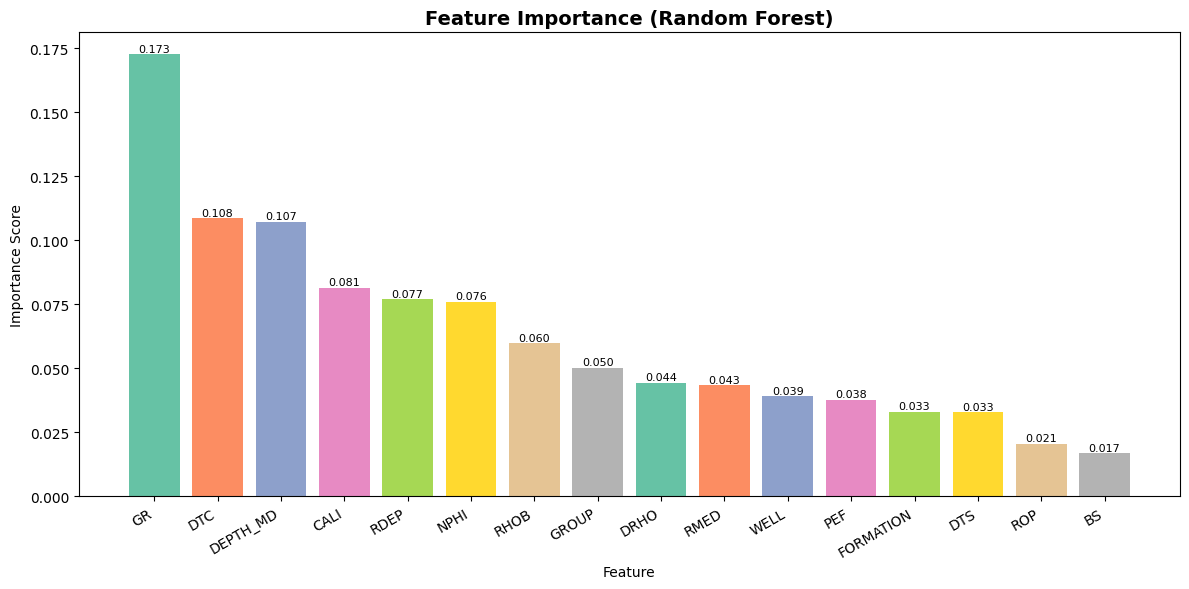

  Feature  Importance
       GR    0.172552
      DTC    0.108499
 DEPTH_MD    0.107220
     CALI    0.081316
     RDEP    0.077005
     NPHI    0.075856
     RHOB    0.059670
    GROUP    0.050116
     DRHO    0.044373
     RMED    0.043358
     WELL    0.039101
      PEF    0.037674
FORMATION    0.033010
      DTS    0.032861
      ROP    0.020545
       BS    0.016845


In [26]:
# Cell 26 - Quick Feature Importance via Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Prepare a quick clean copy
df_fi = df.copy()

# Drop columns not in our 16 features + target
keep_cols = ["DEPTH_MD", "CALI", "RMED", "RDEP", "RHOB", "GR",
             "NPHI", "PEF", "DTC", "DTS", "BS", "ROP", "DRHO",
             "WELL", "FORMATION", "GROUP",
             "FORCE_2020_LITHOFACIES_LITHOLOGY"]

df_fi = df_fi[keep_cols].dropna(subset=["FORCE_2020_LITHOFACIES_LITHOLOGY"])

# Encode categoricals
for col in ["WELL", "FORMATION", "GROUP"]:
    df_fi[col] = LabelEncoder().fit_transform(df_fi[col].astype(str))

# Fill missing with median for quick run
df_fi = df_fi.fillna(df_fi.median())

X = df_fi.drop("FORCE_2020_LITHOFACIES_LITHOLOGY", axis=1)
y = LabelEncoder().fit_transform(df_fi["FORCE_2020_LITHOFACIES_LITHOLOGY"])

# Quick RF with small n_estimators for speed
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Plot
importance_df = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(importance_df["Feature"], importance_df["Importance"],
               color=sns.color_palette("Set2", len(importance_df)))
plt.title("Feature Importance (Random Forest)", fontsize=14, fontweight="bold")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=30, ha="right")
for bar, val in zip(bars, importance_df["Importance"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/feature_importance.png", dpi=150)
plt.show()
print(importance_df.to_string(index=False))

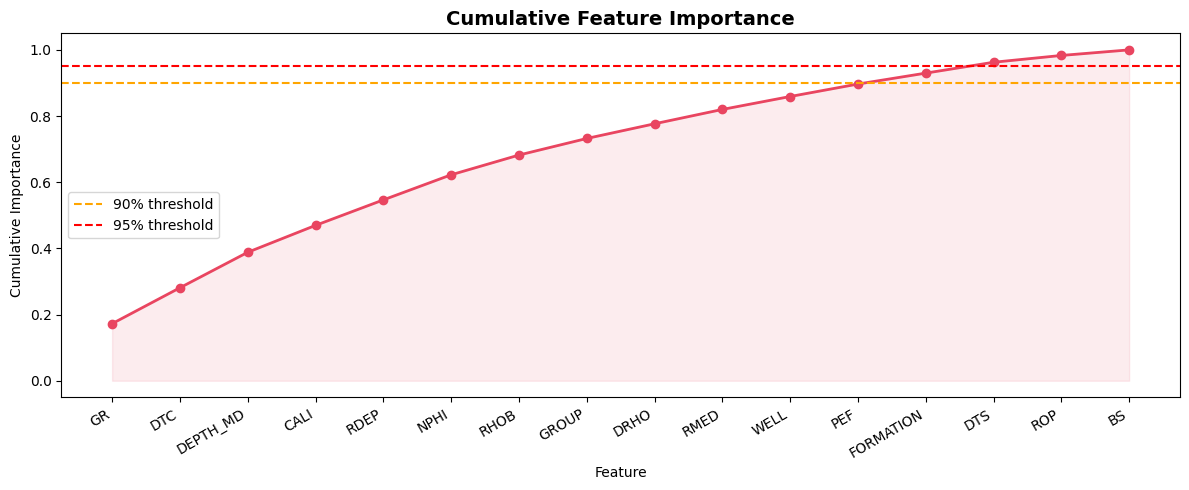

  Features needed for 90% importance: 13
  Features needed for 95% importance: 14


In [27]:
# Cell 27 - Cumulative Feature Importance
importance_df["Cumulative"] = importance_df["Importance"].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(importance_df["Feature"], importance_df["Cumulative"],
         marker="o", color="#e94560", linewidth=2)
plt.axhline(y=0.90, color="orange", linestyle="--", label="90% threshold")
plt.axhline(y=0.95, color="red",    linestyle="--", label="95% threshold")
plt.fill_between(importance_df["Feature"], importance_df["Cumulative"], alpha=0.1, color="#e94560")
plt.title("Cumulative Feature Importance", fontsize=14, fontweight="bold")
plt.xlabel("Feature")
plt.ylabel("Cumulative Importance")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/cumulative_importance.png", dpi=150)
plt.show()

# Print cutoff points
thresh_90 = importance_df[importance_df["Cumulative"] <= 0.90]
thresh_95 = importance_df[importance_df["Cumulative"] <= 0.95]
print(f"  Features needed for 90% importance: {len(thresh_90) + 1}")
print(f"  Features needed for 95% importance: {len(thresh_95) + 1}")

C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\2365825088.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="LITHO_NAME", y=col,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\2365825088.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="LITHO_NAME", y=col,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\2365825088.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="LITHO_NAME", y=col,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\2365825088.py:10: FutureWarning: 

Passing `

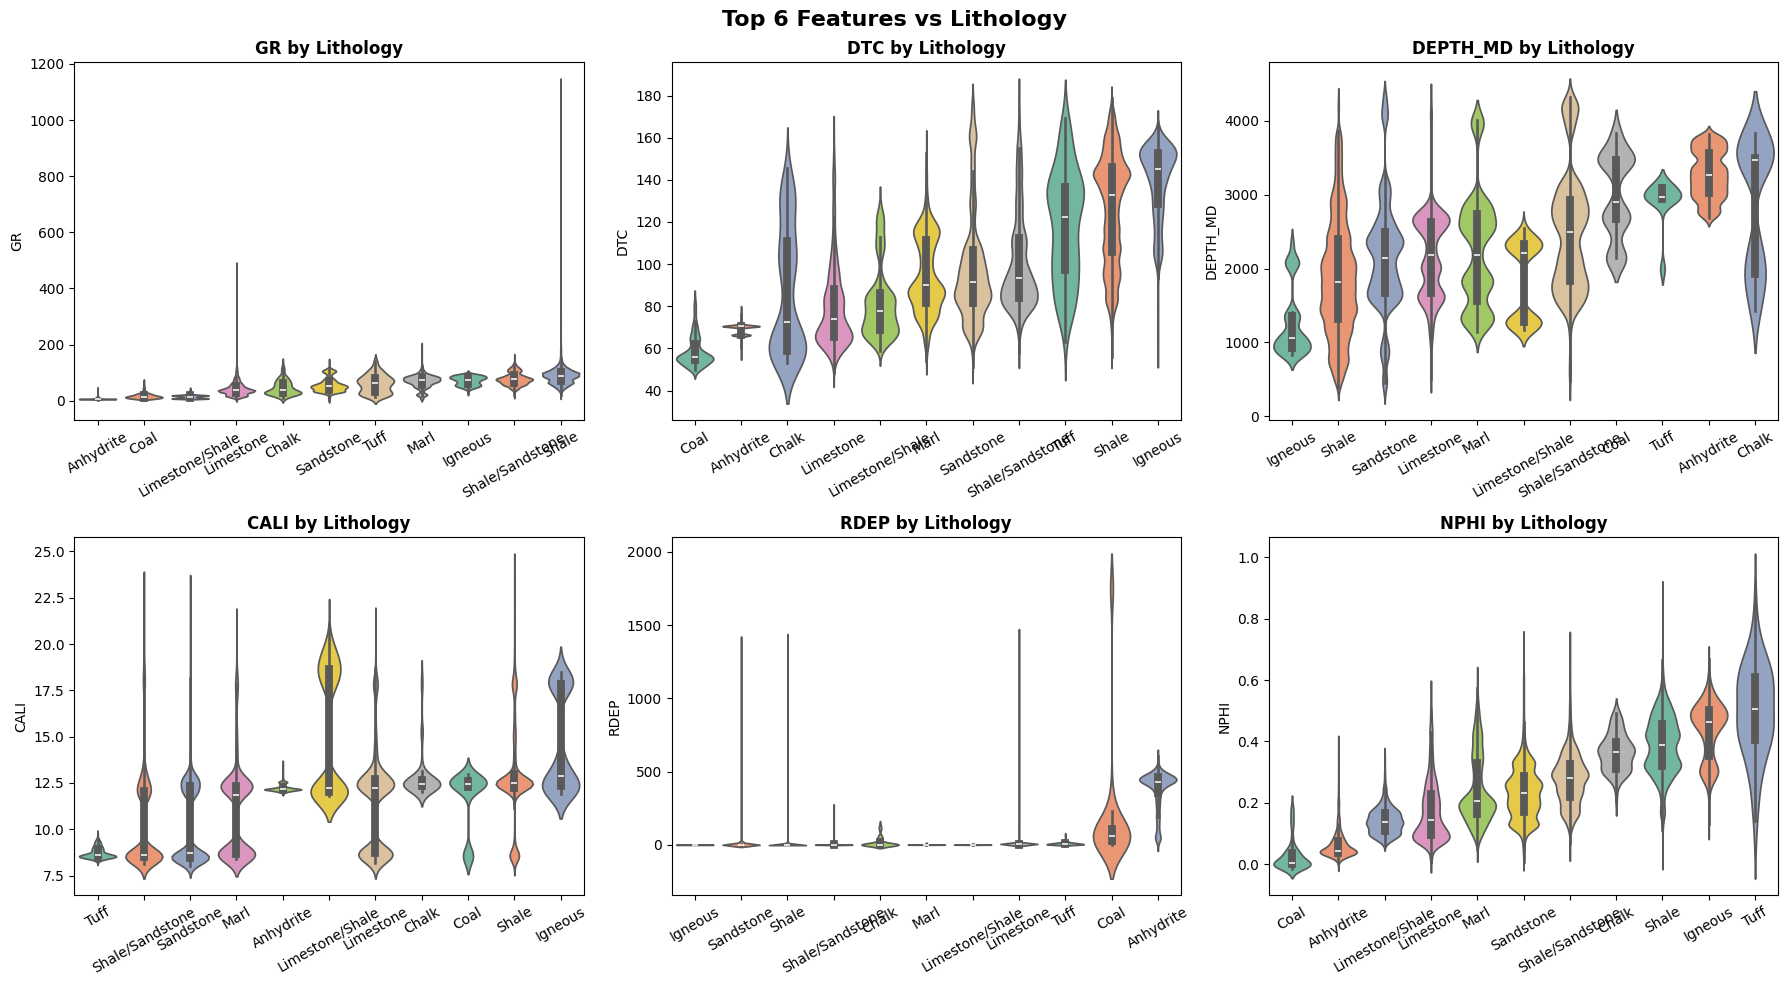

💾 Saved → reports/figures/violin_top6.png


In [28]:
# Cell 28 - Violin Plot: Top 6 Features vs Lithology
top6 = importance_df["Feature"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top6):
    data = df[[col, "LITHO_NAME"]].dropna()
    order = data.groupby("LITHO_NAME")[col].median().sort_values().index
    sns.violinplot(data=data, x="LITHO_NAME", y=col,
                   order=order, palette="Set2", ax=axes[i])
    axes[i].set_title(f"{col} by Lithology", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Top 6 Features vs Lithology", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/violin_top6.png", dpi=150)
plt.show()
print("💾 Saved → reports/figures/violin_top6.png")

In [29]:
# Cell 29 - Low Importance Features
print("⚠️  Features with LOW Importance (< 0.05):\n")
low = importance_df[importance_df["Importance"] < 0.05]
print(low.to_string(index=False))

print("\n✅  Features with HIGH Importance (>= 0.05):\n")
high = importance_df[importance_df["Importance"] >= 0.05]
print(high.to_string(index=False))
print(f"\n  → Recommended features to keep: {len(high)}")

⚠️  Features with LOW Importance (< 0.05):

  Feature  Importance  Cumulative
     DRHO    0.044373    0.776607
     RMED    0.043358    0.819965
     WELL    0.039101    0.859066
      PEF    0.037674    0.896740
FORMATION    0.033010    0.929750
      DTS    0.032861    0.962610
      ROP    0.020545    0.983155
       BS    0.016845    1.000000

✅  Features with HIGH Importance (>= 0.05):

 Feature  Importance  Cumulative
      GR    0.172552    0.172552
     DTC    0.108499    0.281051
DEPTH_MD    0.107220    0.388271
    CALI    0.081316    0.469587
    RDEP    0.077005    0.546592
    NPHI    0.075856    0.622448
    RHOB    0.059670    0.682118
   GROUP    0.050116    0.732235

  → Recommended features to keep: 8


In [30]:
# Cell 30 - Final Feature Selection Decision
print("=" * 60)
print("      🎯 FINAL FEATURE SELECTION DECISION")
print("=" * 60)

final_features = ["GR", "DTC", "DEPTH_MD", "CALI", "RDEP",
                  "NPHI", "RHOB", "GROUP", "DRHO", "RMED",
                  "WELL", "PEF", "FORMATION"]

dropped_features = ["DTS", "ROP", "BS"]

print(f"\n✅ FINAL FEATURES TO KEEP ({len(final_features)}):")
for i, f in enumerate(final_features, 1):
    score = importance_df[importance_df["Feature"] == f]["Importance"].values[0]
    print(f"   {i:2}. {f:12} → {score:.4f}")

total_importance = importance_df[importance_df["Feature"].isin(final_features)]["Importance"].sum()
print(f"\n   📊 Total importance covered: {total_importance:.2%}")

print(f"\n❌ DROPPED FEATURES ({len(dropped_features)}):")
for f in dropped_features:
    score = importance_df[importance_df["Feature"] == f]["Importance"].values[0]
    print(f"   • {f:12} → {score:.4f}")

print("\n" + "=" * 60)
print("  📓 Next → 02_Data_Preprocessing.ipynb")
print("=" * 60)

      🎯 FINAL FEATURE SELECTION DECISION

✅ FINAL FEATURES TO KEEP (13):
    1. GR           → 0.1726
    2. DTC          → 0.1085
    3. DEPTH_MD     → 0.1072
    4. CALI         → 0.0813
    5. RDEP         → 0.0770
    6. NPHI         → 0.0759
    7. RHOB         → 0.0597
    8. GROUP        → 0.0501
    9. DRHO         → 0.0444
   10. RMED         → 0.0434
   11. WELL         → 0.0391
   12. PEF          → 0.0377
   13. FORMATION    → 0.0330

   📊 Total importance covered: 92.97%

❌ DROPPED FEATURES (3):
   • DTS          → 0.0329
   • ROP          → 0.0205
   • BS           → 0.0168

  📓 Next → 02_Data_Preprocessing.ipynb


In [31]:
# Cell 31 - Class Imbalance Strategy
print("=" * 60)
print("      ⚖️  CLASS IMBALANCE STRATEGY")
print("=" * 60)

class_counts = df["FORCE_2020_LITHOFACIES_LITHOLOGY"].value_counts()
total = len(df.dropna(subset=["FORCE_2020_LITHOFACIES_LITHOLOGY"]))

print(f"\n{'Class':<12} {'Count':>8} {'%':>8} {'Strategy'}")
print("-" * 55)

for cls, count in class_counts.items():
    pct = count / total * 100
    name = litho_map.get(cls, str(cls))
    if pct > 10:
        strategy = "✅ Sufficient"
    elif pct > 2:
        strategy = "⚠️  Class Weight"
    else:
        strategy = "🔴 SMOTE needed"
    print(f"{name:<18} {count:>8,} {pct:>7.1f}%  {strategy}")

print(f"""
{'=' * 60}
📋 STRATEGY:
   Phase 1 → class_weight='balanced' in model
   Phase 2 → SMOTE on rare classes if needed
             (Coal, Chalk, Tuff, Igneous)
   
   ⚠️  SMOTE applied ONLY on training data
       NEVER on test data!
{'=' * 60}
""")

      ⚖️  CLASS IMBALANCE STRATEGY

Class           Count        % Strategy
-------------------------------------------------------
Shale                69,305    57.1%  ✅ Sufficient
Sandstone            14,794    12.2%  ✅ Sufficient
Shale/Sandstone      10,507     8.7%  ⚠️  Class Weight
Limestone             8,721     7.2%  ⚠️  Class Weight
Anhydrite             6,498     5.4%  ⚠️  Class Weight
Marl                  5,266     4.3%  ⚠️  Class Weight
Limestone/Shale       2,905     2.4%  ⚠️  Class Weight
Igneous               2,366     1.9%  🔴 SMOTE needed
Coal                    597     0.5%  🔴 SMOTE needed
Chalk                   269     0.2%  🔴 SMOTE needed
Tuff                    196     0.2%  🔴 SMOTE needed

📋 STRATEGY:
   Phase 1 → class_weight='balanced' in model
   Phase 2 → SMOTE on rare classes if needed
             (Coal, Chalk, Tuff, Igneous)
   
   ⚠️  SMOTE applied ONLY on training data
       NEVER on test data!



In [34]:
# Cell 32 - Class Combination Analysis
print("📊 CLASS COMBINATION ANALYSIS\n")

litho_map = {
    30000: "Sandstone",
    65000: "Shale",
    65030: "Shale",          # merge with Shale
    70000: "Limestone",
    70032: "Limestone",      # merge with Limestone
    74000: "Chalk",
    80000: "Marl",
    86000: "Coal",
    88000: "Anhydrite",
    90000: "Tuff",
    99000: "Igneous"
}

df["LITHO_MERGED"] = df["FORCE_2020_LITHOFACIES_LITHOLOGY"].map(litho_map)

print("After merging Shale/Sandstone → Shale")
print("After merging Limestone/Shale → Limestone\n")

merged_counts = df["LITHO_MERGED"].value_counts()
total = merged_counts.sum()

print(f"{'Class':<20} {'Count':>8} {'%':>8} {'Status'}")
print("-" * 55)
for cls, count in merged_counts.items():
    pct = count / total * 100
    if pct > 10:
        status = "✅ Healthy"
    elif pct > 2:
        status = "⚠️  Moderate"
    elif pct > 0.5:
        status = "🟡 SMOTE"
    else:
        status = "🔴 SMOTE or Drop"
    print(f"{cls:<20} {count:>8,} {pct:>7.2f}%  {status}")

print(f"\n  Classes before : 11")
print(f"  Classes after  : {merged_counts.nunique()}")



📊 CLASS COMBINATION ANALYSIS

After merging Shale/Sandstone → Shale
After merging Limestone/Shale → Limestone

Class                   Count        % Status
-------------------------------------------------------
Shale                  79,812   65.73%  ✅ Healthy
Sandstone              14,794   12.18%  ✅ Healthy
Limestone              11,626    9.57%  ⚠️  Moderate
Anhydrite               6,498    5.35%  ⚠️  Moderate
Marl                    5,266    4.34%  ⚠️  Moderate
Igneous                 2,366    1.95%  🟡 SMOTE
Coal                      597    0.49%  🔴 SMOTE or Drop
Chalk                     269    0.22%  🔴 SMOTE or Drop
Tuff                      196    0.16%  🔴 SMOTE or Drop

  Classes before : 11
  Classes after  : 9


C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\1048825791.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="LITHO_MERGED", y=feat,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\1048825791.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="LITHO_MERGED", y=feat,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\1048825791.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="LITHO_MERGED", y=feat,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\1048825791.py:14: FutureWarning: 

Passing `

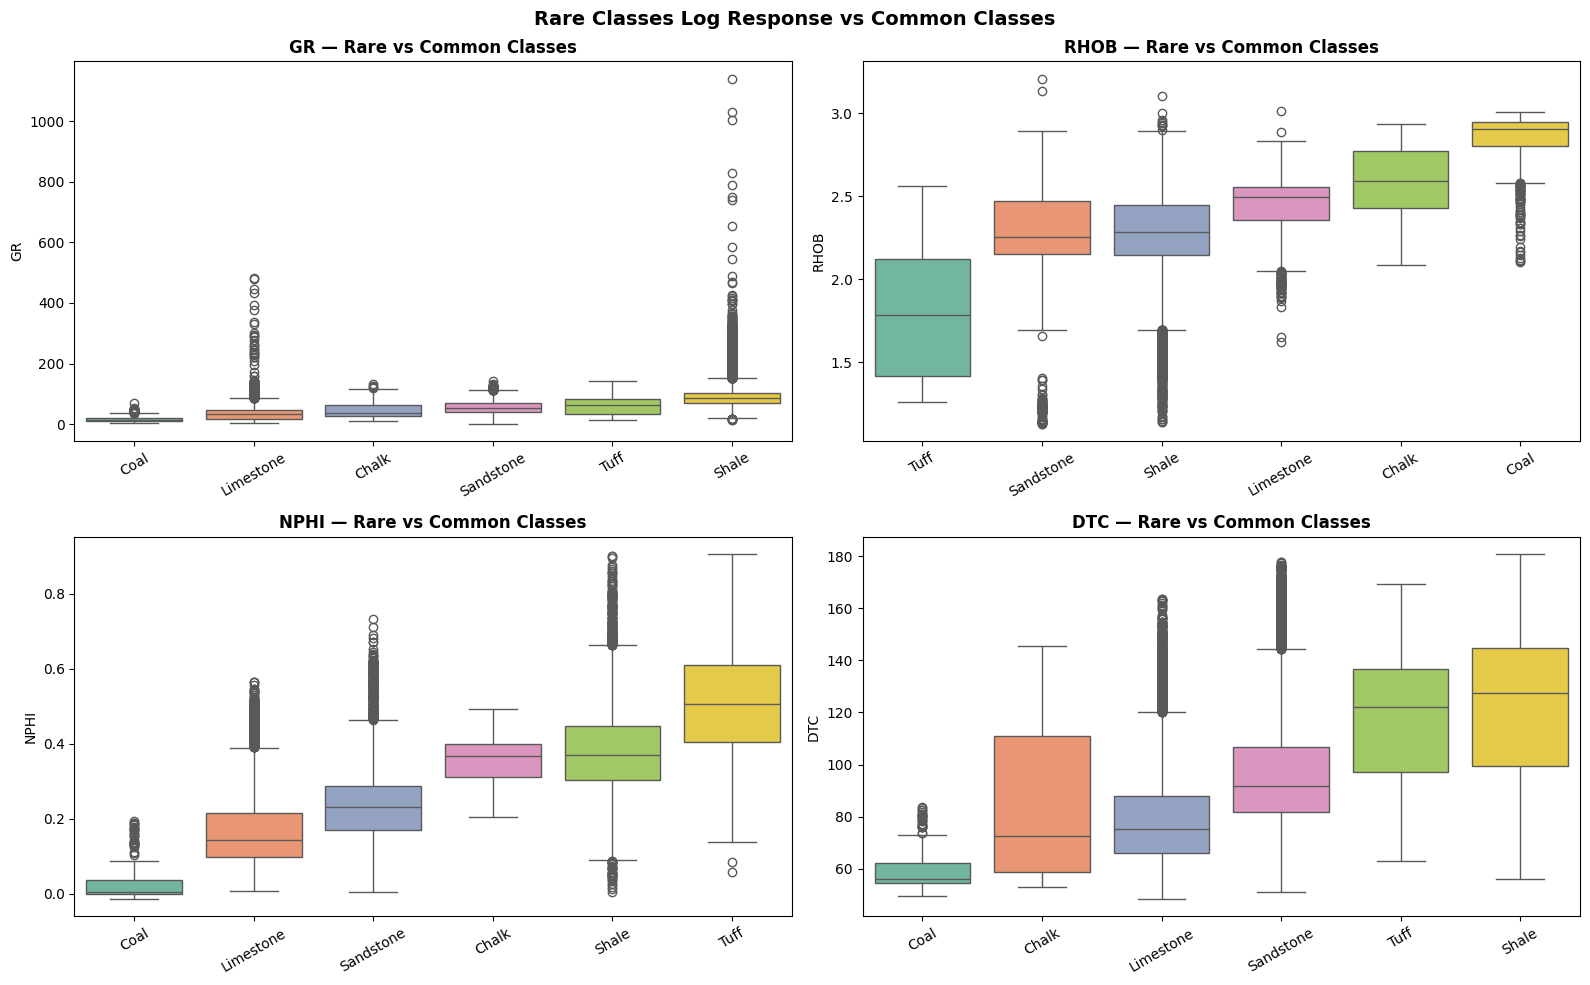

💾 Saved → reports/figures/rare_classes_check.png


In [35]:
# Cell 33 - Rare Classes Log Response Check
rare_classes = ["Coal", "Chalk", "Tuff"]
common_classes = ["Shale", "Sandstone", "Limestone"]
check_classes = rare_classes + common_classes

features_to_check = ["GR", "RHOB", "NPHI", "DTC"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features_to_check):
    data = df[df["LITHO_MERGED"].isin(check_classes)][[feat, "LITHO_MERGED"]].dropna()
    order = data.groupby("LITHO_MERGED")[feat].median().sort_values().index
    sns.boxplot(data=data, x="LITHO_MERGED", y=feat,
                order=order, palette="Set2", ax=axes[i])
    axes[i].set_title(f"{feat} — Rare vs Common Classes", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Rare Classes Log Response vs Common Classes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/rare_classes_check.png", dpi=150)
plt.show()
print("💾 Saved → reports/figures/rare_classes_check.png")

C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\1146155866.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="LITHO_MERGED", y=feat,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\1146155866.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="LITHO_MERGED", y=feat,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\1146155866.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="LITHO_MERGED", y=feat,
C:\Users\hnaif\AppData\Local\Temp\ipykernel_38800\1146155866.py:9: FutureWarning: 

Passing `pale

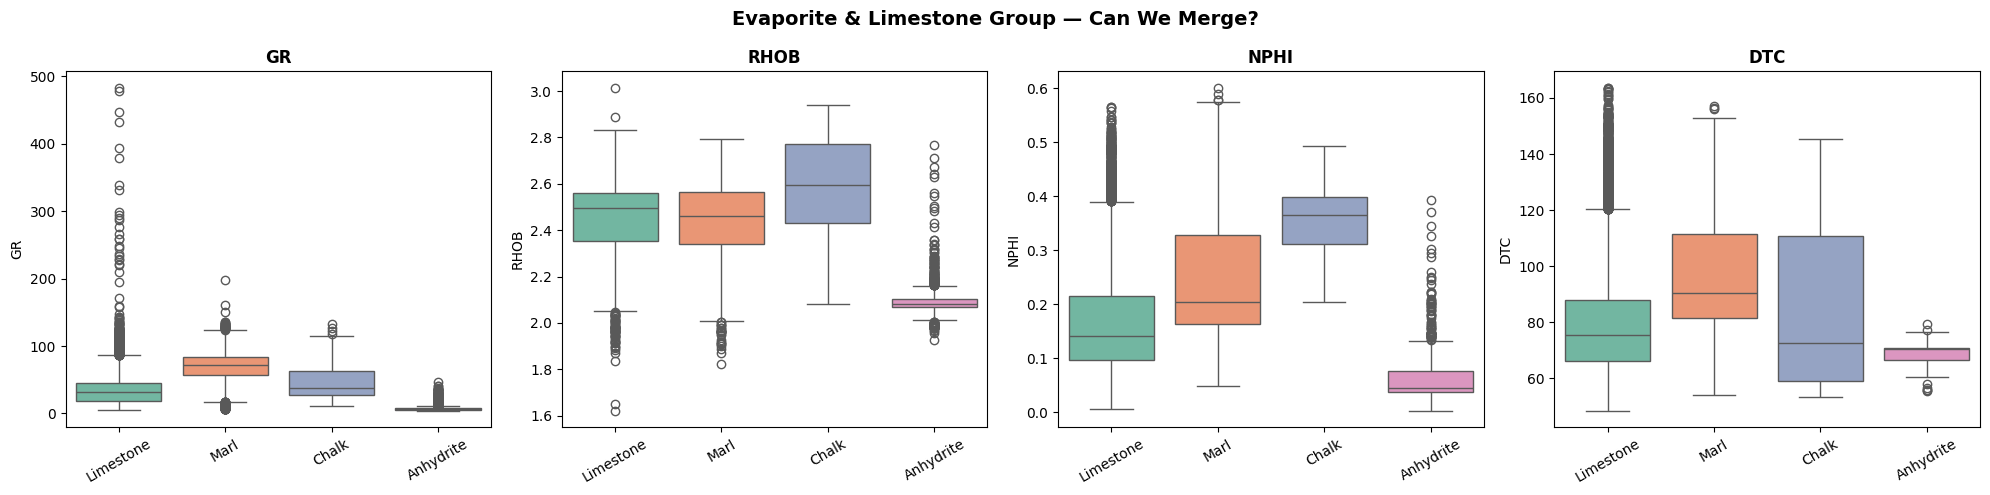

In [36]:
# Cell 35 - Evaporite & Limestone Group Check
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

groups_to_check = ["Anhydrite", "Marl", "Limestone", "Chalk"]
features_to_check = ["GR", "RHOB", "NPHI", "DTC"]

for i, feat in enumerate(features_to_check):
    data = df[df["LITHO_MERGED"].isin(groups_to_check)][[feat, "LITHO_MERGED"]].dropna()
    sns.boxplot(data=data, x="LITHO_MERGED", y=feat,
                palette="Set2", ax=axes[i])
    axes[i].set_title(f"{feat}", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Evaporite & Limestone Group — Can We Merge?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("D:/Python/Lithofacies_Classification_NMM/reports/figures/evaporite_limestone_check.png", dpi=150)
plt.show()

In [37]:
# Cell 36 - Final Class Mapping & Strategy
print("=" * 60)
print("      🗺️  FINAL CLASS MAPPING & STRATEGY")
print("=" * 60)

final_litho_map = {
    30000 : "Sandstone",
    65000 : "Shale",
    65030 : "Shale",       # merged
    70000 : "Limestone",
    70032 : "Limestone",   # merged
    74000 : "Limestone",   # Chalk merged
    80000 : "Marl",
    86000 : "Coal",
    88000 : "Anhydrite",
    90000 : "Tuff",
    99000 : "Igneous"
}

df["LITHO_FINAL"] = df["FORCE_2020_LITHOFACIES_LITHOLOGY"].map(final_litho_map)

final_counts = df["LITHO_FINAL"].value_counts()
total = final_counts.sum()

print(f"\n{'Class':<15} {'Count':>8} {'%':>8}   {'Strategy'}")
print("-" * 60)
for cls, count in final_counts.items():
    pct = count / total * 100
    if pct > 5:
        strategy = "✅ Healthy"
    elif pct > 1:
        strategy = "⚖️  Class weight"
    else:
        strategy = "⚖️  Class weight + Balanced RF"
    print(f"  {cls:<13} {count:>8,} {pct:>7.2f}%   {strategy}")

print(f"""
{'=' * 60}
📋 MERGES APPLIED:
   • Shale/Sandstone  → Shale
   • Limestone/Shale  → Limestone
   • Chalk            → Limestone
   • Classes reduced  : 11 → 8

📋 IMBALANCE STRATEGY (No SMOTE):
   • class_weight = 'balanced'     (all models)
   • Balanced Random Forest        (primary model)
   • XGBoost scale_pos_weight      (secondary model)
   • Focal Loss                    (if Neural Network)

📋 MODELS TO TRY IN 04_Model_Training:
   1. Balanced Random Forest       ← start here
   2. XGBoost with class weights
   3. LightGBM with class weights
   4. Neural Network + Focal Loss  ← if needed for 96%+

{'=' * 60}
  📓 Exploration complete! Next → 02_Data_Preprocessing.ipynb
{'=' * 60}
""")

      🗺️  FINAL CLASS MAPPING & STRATEGY

Class              Count        %   Strategy
------------------------------------------------------------
  Shale           79,812   65.73%   ✅ Healthy
  Sandstone       14,794   12.18%   ✅ Healthy
  Limestone       11,895    9.80%   ✅ Healthy
  Anhydrite        6,498    5.35%   ✅ Healthy
  Marl             5,266    4.34%   ⚖️  Class weight
  Igneous          2,366    1.95%   ⚖️  Class weight
  Coal               597    0.49%   ⚖️  Class weight + Balanced RF
  Tuff               196    0.16%   ⚖️  Class weight + Balanced RF

📋 MERGES APPLIED:
   • Shale/Sandstone  → Shale
   • Limestone/Shale  → Limestone
   • Chalk            → Limestone
   • Classes reduced  : 11 → 8

📋 IMBALANCE STRATEGY (No SMOTE):
   • class_weight = 'balanced'     (all models)
   • Balanced Random Forest        (primary model)
   • XGBoost scale_pos_weight      (secondary model)
   • Focal Loss                    (if Neural Network)

📋 MODELS TO TRY IN 04_Model_Training:


In [38]:
# Test config.py import
import sys
sys.path.append("D:/Python/Lithofacies_Classification_NMM/src")
from config import *

print("📁 PATHS:")
print(f"   Base     : {BASE_PATH}")
print(f"   Raw      : {RAW_PATH}")
print(f"   Processed: {PROCESSED_PATH}")
print(f"   Models   : {MODEL_PATH}")
print(f"   Figures  : {FIGURES_PATH}")

print(f"\n🎯 TARGET    : {TARGET}")
print(f"🎯 TARGET CLEAN: {TARGET_CLEAN}")

print(f"\n✅ FEATURES ({len(FINAL_FEATURES)}):")
for f in FINAL_FEATURES:
    print(f"   • {f}")

print(f"\n🗑️  COLUMNS TO DROP ({len(COLUMNS_TO_DROP)}):")
for c in COLUMNS_TO_DROP:
    print(f"   • {c}")

print(f"\n🗺️  CLASS MAPPING ({len(LITHO_MAP)} → {len(FINAL_CLASSES)}):")
for code, name in LITHO_MAP.items():
    print(f"   {code} → {name}")

✅ Config loaded!
📁 PATHS:
   Base     : D:/Python/Lithofacies_Classification_NMM
   Raw      : D:/Python/Lithofacies_Classification_NMM\data/raw
   Processed: D:/Python/Lithofacies_Classification_NMM\data/processed
   Models   : D:/Python/Lithofacies_Classification_NMM\models
   Figures  : D:/Python/Lithofacies_Classification_NMM\reports/figures

🎯 TARGET    : FORCE_2020_LITHOFACIES_LITHOLOGY
🎯 TARGET CLEAN: LITHO_FINAL

✅ FEATURES (13):
   • DEPTH_MD
   • GR
   • DTC
   • CALI
   • RDEP
   • NPHI
   • RHOB
   • DRHO
   • RMED
   • PEF
   • WELL
   • FORMATION
   • GROUP

🗑️  COLUMNS TO DROP (18):
   • MUDWEIGHT
   • SGR
   • RXO
   • RMIC
   • RSHA
   • DCAL
   • SP
   • ROPA
   • DTS
   • ROP
   • BS
   • Unnamed: 0
   • DEPT
   • Z_LOC
   • X_LOC
   • Y_LOC
   • SOURCE_FILE
   • FORCE_2020_LITHOFACIES_CONFIDENCE

🗺️  CLASS MAPPING (11 → 8):
   30000 → Sandstone
   65000 → Shale
   65030 → Shale
   70000 → Limestone
   70032 → Limestone
   74000 → Limestone
   80000 → Marl
   86000 →